# AI-Based Resume Screening System
Minor Project (Individual) | Python, Pandas, NumPy, scikit-learn, NLTK

**Pipeline:** Dataset Collection → Cleaning → Preprocessing → Skill Extraction → Keyword Matching → Classification → Job Role Matching → Score & Recommendation → Testing

**Dataset:** Kaggle *Resume Dataset* (`UpdatedResumeDataSet.csv`, columns `Category`, `Resume`). Place it at `data/UpdatedResumeDataSet.csv`.

## 0. Setup

In [1]:
import os, re, json, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk, joblib
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)
for d in ["data", "models", "screenshots", "sample_resumes", "outputs"]:
    os.makedirs(d, exist_ok=True)

RAW_PATH = "data/UpdatedResumeDataSet.csv"
RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


## 1. Resume Dataset Collection

In [2]:
if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(f"Download the Kaggle 'Resume Dataset' and save it as {RAW_PATH}")

df = pd.read_csv(RAW_PATH, encoding="utf-8")
df = df.rename(columns={"Resume_str": "Resume"})[["Category", "Resume"]]
print("Shape:", df.shape)
print("Null values:\n", df.isnull().sum())
print("Duplicate resumes:", df.duplicated(subset="Resume").sum())
df.head()

Shape: (962, 2)
Null values:
 Category    0
Resume      0
dtype: int64
Duplicate resumes: 796


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


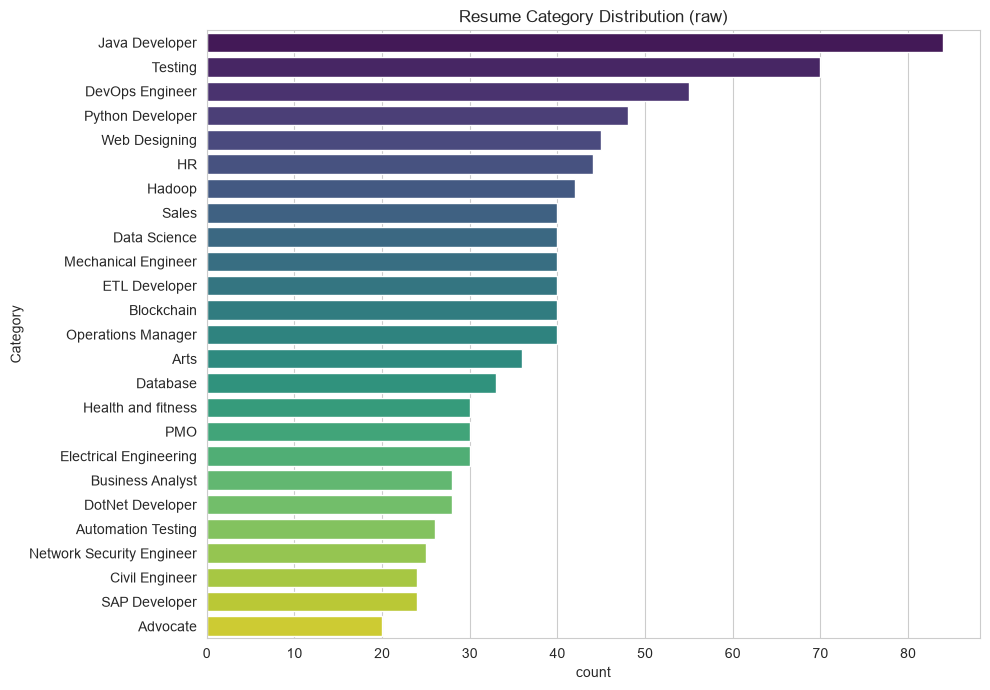

In [3]:
plt.figure(figsize=(10, 7))
order = df["Category"].value_counts().index
sns.countplot(y="Category", data=df, order=order, palette="viridis")
plt.title("Resume Category Distribution (raw)")
plt.tight_layout()
plt.savefig("screenshots/01_category_distribution.png", dpi=150)
plt.show()

## 2. Data Cleaning

In [4]:
def clean_text(text):
    """Light cleaning: keeps + # . so skills like c++, c#, node.js survive."""
    t = str(text).lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)                       # URLs
    t = re.sub(r"\S+@\S+", " ", t)                                 # emails
    t = re.sub(r"\+\d{1,3}[\s-]?\d{10}|\b\d{10}\b|\(?\d{3}\)?[\s.-]\d{3}[\s.-]\d{4}", " ", t)  # phones
    t = t.encode("ascii", "ignore").decode()                        # non-ascii
    t = re.sub(r"[^a-z0-9+#.\s]", " ", t)                           # special chars
    t = re.sub(r"\s+", " ", t).strip()
    return t

before = len(df)
df = df.dropna(subset=["Category", "Resume"])
df = df.drop_duplicates(subset="Resume").reset_index(drop=True)
df["Category"] = df["Category"].str.strip()
df["clean_text"] = df["Resume"].apply(clean_text)
df = df[df["clean_text"].str.len() > 50].reset_index(drop=True)
print(f"Rows: {before} -> {len(df)} after removing nulls/duplicates/very short resumes")
df[["Category", "clean_text"]].head(3)

Rows: 962 -> 166 after removing nulls/duplicates/very short resumes


,Category,clean_text
0,Data Science,skills programming languages python pandas num...
1,Data Science,education details may 2013 to may 2017 b.e uit...
2,Data Science,areas of interest deep learning control system...


## 3. Text Preprocessing (tokenize, stopword removal, lemmatization)

In [5]:
STOP = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = re.findall(r"[a-z][a-z0-9+#]*", text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP and len(t) > 1]
    return " ".join(tokens)

df["processed_text"] = df["clean_text"].apply(preprocess)
print(df.loc[0, "clean_text"][:300], "\n---\n", df.loc[0, "processed_text"][:300])

skills programming languages python pandas numpy scipy scikit learn matplotlib sql java javascript jquery. machine learning regression svm nave bayes knn random forest decision trees boosting techniques cluster analysis word embedding sentiment analysis natural language processing dimensionality red 
---
 skill programming language python panda numpy scipy scikit learn matplotlib sql java javascript jquery machine learning regression svm nave bayes knn random forest decision tree boosting technique cluster analysis word embedding sentiment analysis natural language processing dimensionality reduction


## 4. Skill Extraction (skill dictionary + regex matching)

In [6]:
# Required skills per job role. Role names match the dataset categories.
ROLE_SKILLS = {
    "Data Science": ["python", "machine learning", "deep learning", "pandas", "numpy", "scikit-learn", "tensorflow",
                     "keras", "pytorch", "nlp", "statistics", "data visualization", "matplotlib", "sql", "tableau",
                     "power bi", "data analysis", "feature engineering"],
    "Python Developer": ["python", "django", "flask", "fastapi", "rest api", "sql", "postgresql", "mysql", "git",
                         "docker", "pandas", "unit testing", "oop", "linux", "mongodb", "celery"],
    "Java Developer": ["java", "spring", "spring boot", "hibernate", "jpa", "maven", "junit", "rest api", "microservices",
                       "mysql", "sql", "git", "jenkins", "jsp", "servlets", "oop"],
    "Web Designing": ["html", "css", "javascript", "react", "jquery", "bootstrap", "responsive design", "figma",
                      "photoshop", "angular", "typescript", "sass", "ui/ux", "wordpress", "node.js"],
    "DevOps Engineer": ["docker", "kubernetes", "jenkins", "terraform", "ansible", "aws", "azure", "linux", "ci/cd",
                        "git", "bash", "python", "prometheus", "grafana", "nginx", "helm", "gitlab"],
    "Testing": ["manual testing", "selenium", "test cases", "junit", "testng", "jira", "bug tracking", "api testing",
                "postman", "regression testing", "sql", "agile", "java", "test plan", "cucumber", "automation testing"],
    "Database": ["sql", "mysql", "oracle", "postgresql", "sql server", "pl/sql", "stored procedures", "database design",
                 "indexing", "query optimization", "backup", "mongodb", "etl", "data modeling", "performance tuning",
                 "normalization"],
    "Network Security Engineer": ["firewall", "vpn", "ids", "ips", "cisco", "siem", "vulnerability assessment",
                                  "penetration testing", "tcp/ip", "network security", "wireshark", "nmap", "palo alto",
                                  "fortinet", "encryption", "incident response", "splunk"],
    "HR": ["recruitment", "talent acquisition", "onboarding", "payroll", "employee engagement", "performance management",
           "hris", "sourcing", "interviewing", "compensation", "labor law", "training and development",
           "employee relations", "ms excel", "hr policies"],
}
EXTRA_SKILLS = ["c++", "c#", "javascript", "agile", "scrum", "communication", "leadership", "excel", "github", "azure devops",
                "react native", "power automate", "servicenow", "cloud computing", "gcp", "hadoop", "spark", "r programming"]

ALL_SKILLS = sorted({s for v in ROLE_SKILLS.values() for s in v} | set(EXTRA_SKILLS))
print("Total skills in dictionary:", len(ALL_SKILLS))

with open("data/skills.json", "w") as f:
    json.dump({"role_skills": ROLE_SKILLS, "all_skills": ALL_SKILLS}, f, indent=2)

# Compile word-boundary patterns (skill text is normalised the same way as resume text)
SKILL_PATTERNS = {
    s: re.compile(r"(?<![a-z0-9+#])" + re.escape(clean_text(s)) + r"(?![a-z0-9+#])") for s in ALL_SKILLS
}

def extract_skills(clean):
    return sorted(s for s, p in SKILL_PATTERNS.items() if p.search(clean))

df["skills"] = df["clean_text"].apply(extract_skills)
df["n_skills"] = df["skills"].str.len()
print("Average skills found per resume:", round(df["n_skills"].mean(), 2))
df[["Category", "skills", "n_skills"]].head()

Total skills in dictionary: 142
Average skills found per resume: 5.08


,Category,skills,n_skills
0,Data Science,"[angular, bootstrap, css, deep learning, docke...",22
1,Data Science,"[aws, github, keras, machine learning, python]",5
2,Data Science,"[data analysis, deep learning, django, excel, ...",12
3,Data Science,"[c#, communication, deep learning, etl, machin...",14
4,Data Science,"[data analysis, java, python]",3


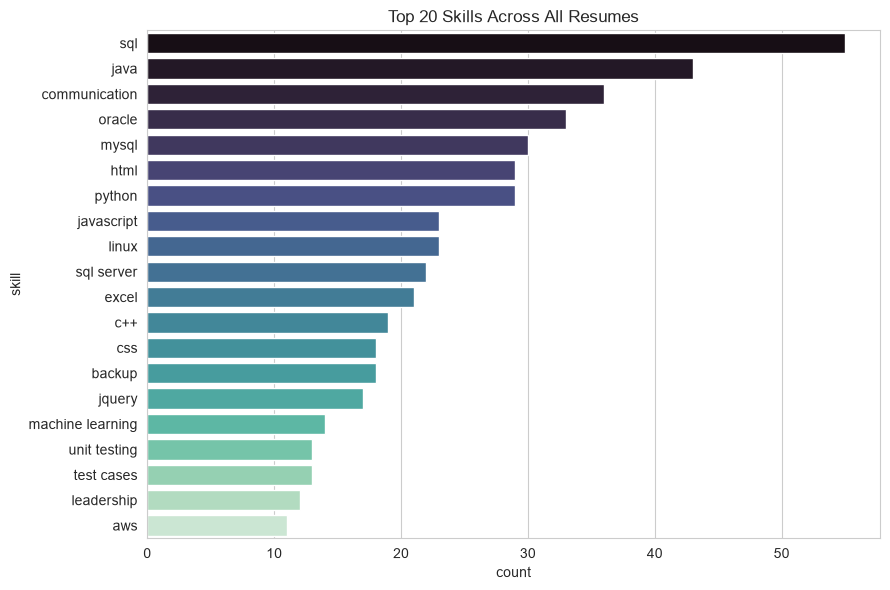

In [7]:
counts = Counter(s for lst in df["skills"] for s in lst)
top = pd.DataFrame(counts.most_common(20), columns=["skill", "count"])
plt.figure(figsize=(9, 6))
sns.barplot(x="count", y="skill", data=top, palette="mako")
plt.title("Top 20 Skills Across All Resumes")
plt.tight_layout()
plt.savefig("screenshots/02_top_skills.png", dpi=150)
plt.show()

## 5. Job Descriptions & Keyword Matching

In [9]:
JOB_DESCRIPTIONS = {
    "Data Science": "We are hiring a Data Scientist to build machine learning and deep learning models, perform statistical analysis, feature engineering and data visualization on large datasets using Python, pandas, scikit-learn and SQL.",
    "Python Developer": "Looking for a Python Developer to design backend services and REST APIs using Django, Flask or FastAPI, work with relational and NoSQL databases, write unit tests and deploy using Docker and Git.",
    "Java Developer": "Hiring a Java Developer experienced in Spring Boot, Hibernate, microservices and REST APIs, with Maven, JUnit, MySQL and Jenkins for build and delivery.",
    "Web Designing": "Seeking a Web Designer/Front-end Developer skilled in HTML, CSS, JavaScript, React, Bootstrap and responsive design, with UI/UX sense and tools like Figma and Photoshop.",
    "DevOps Engineer": "DevOps Engineer needed to manage CI/CD pipelines, containers and orchestration with Docker and Kubernetes, infrastructure as code with Terraform and Ansible, cloud on AWS or Azure, and monitoring with Prometheus and Grafana.",
    "Testing": "QA/Test Engineer required for manual and automation testing, writing test plans and test cases, using Selenium, TestNG, Postman, JIRA, regression and API testing in an Agile team.",
    "Database": "Database Administrator/Developer to design schemas, write stored procedures and PL/SQL, optimize queries and indexing, manage backups and performance tuning on Oracle, MySQL, PostgreSQL or SQL Server.",
    "Network Security Engineer": "Network Security Engineer to manage firewalls, VPNs, IDS/IPS and SIEM tools, perform vulnerability assessment and penetration testing, and handle incident response using Palo Alto, Fortinet, Cisco, Wireshark and Splunk.",
    "HR": "HR Executive for end-to-end recruitment, talent acquisition, onboarding, payroll, employee engagement, performance management, HRIS and HR policy administration.",
}
with open("data/job_descriptions.json", "w") as f:
    json.dump(JOB_DESCRIPTIONS, f, indent=2)

def keyword_match(clean, role):
    found = set(extract_skills(clean))
    required = ROLE_SKILLS[role]
    matched = [s for s in required if s in found]
    missing = [s for s in required if s not in found]
    return matched, missing

# demo on one resume
r = df.iloc[0]
m, x = keyword_match(r["clean_text"], r["Category"])
print("Resume category:", r["Category"])
print("Matched:", m)
print("Missing:", x)

Resume category: Data Science
Matched: ['python', 'machine learning', 'deep learning', 'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'sql', 'tableau']
Missing: ['tensorflow', 'keras', 'pytorch', 'nlp', 'statistics', 'data visualization', 'power bi', 'data analysis', 'feature engineering']


## 6. Resume Classification (TF-IDF + ML models)

In [10]:
df.to_csv("data/cleaned_resumes.csv", index=False)   # cleaned dataset deliverable

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df["processed_text"], df["Category"], test_size=0.2, stratify=df["Category"], random_state=RANDOM_STATE
)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_txt)
X_test = tfidf.transform(X_test_txt)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (132, 4796) Test: (34, 4796)


,Model,Accuracy,Macro F1
0,Linear SVC,0.882353,0.820952
1,Logistic Regression,0.852941,0.776667
2,Naive Bayes,0.794118,0.710667


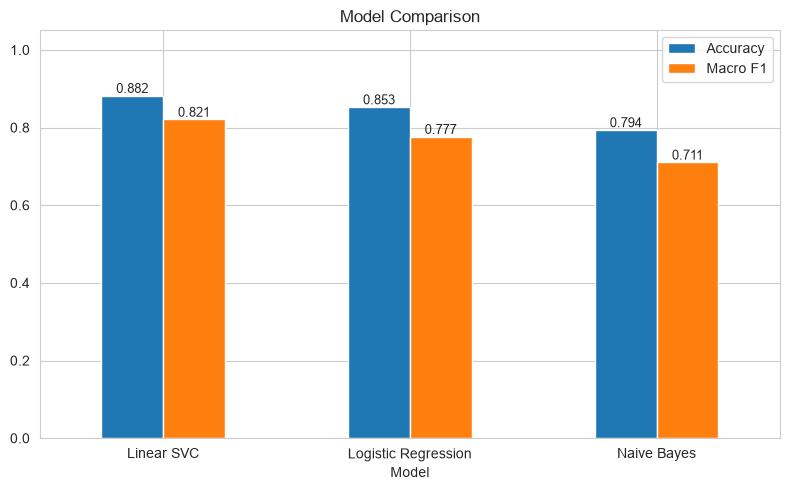

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, C=10),
    "Linear SVC": LinearSVC(C=1.0),
    "Naive Bayes": MultinomialNB(alpha=0.1),
}
rows, preds = [], {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    p = mdl.predict(X_test)
    preds[name] = p
    rows.append({"Model": name, "Accuracy": accuracy_score(y_test, p), "Macro F1": f1_score(y_test, p, average="macro")})
results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results.to_csv("outputs/model_comparison.csv", index=False)
display(results)

ax = results.set_index("Model")[["Accuracy", "Macro F1"]].plot(kind="bar", figsize=(8, 5), ylim=(0, 1.05), rot=0)
ax.set_title("Model Comparison")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=9)
plt.tight_layout()
plt.savefig("screenshots/03_model_comparison.png", dpi=150)
plt.show()

### 6b. Cross-validation (reliable estimate for a small dataset)
After removing duplicates only ~166 unique resumes remain, so a single 20% test split (~34 resumes) is noisy. Stratified 3-fold cross-validation (TF-IDF fitted inside each fold, so no leakage) gives a more trustworthy comparison.

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, mdl in models.items():
    pipe = make_pipeline(TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True), mdl)
    sc = cross_val_score(pipe, df["processed_text"], df["Category"], cv=skf, scoring="accuracy")
    cv_rows.append({"Model": name, "CV Accuracy (mean)": sc.mean(), "CV Std": sc.std()})
cv_results = pd.DataFrame(cv_rows).sort_values("CV Accuracy (mean)", ascending=False)
cv_results.to_csv("outputs/cross_validation_results.csv", index=False)
display(cv_results)

,Model,CV Accuracy (mean),CV Std
1,Linear SVC,0.879870,0.043910
0,Logistic Regression,0.837879,0.062581
2,Naive Bayes,0.662987,0.042186


Best model: Linear SVC
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         2
                     Arts       1.00      1.00      1.00         1
       Automation Testing       0.50      1.00      0.67         1
               Blockchain       1.00      1.00      1.00         1
         Business Analyst       0.50      1.00      0.67         1
           Civil Engineer       1.00      1.00      1.00         1
             Data Science       1.00      1.00      1.00         2
                 Database       1.00      1.00      1.00         2
          DevOps Engineer       1.00      1.00      1.00         1
         DotNet Developer       1.00      1.00      1.00         2
            ETL Developer       1.00      1.00      1.00         1
   Electrical Engineering       1.00      1.00      1.00         1
                       HR       1.00      1.00      1.00         2
                   Hadoop       1.00  

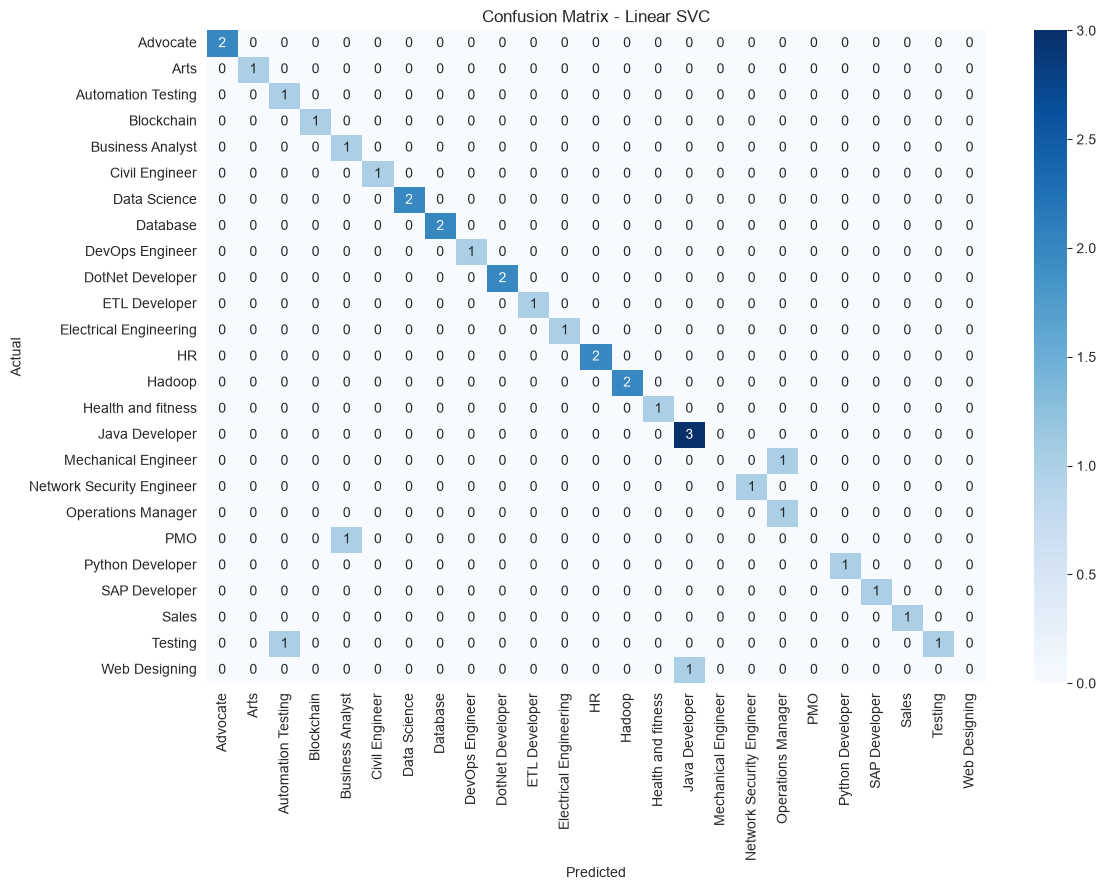

In [13]:
best_name = results.loc[0, "Model"]
print("Best model:", best_name)
print(classification_report(y_test, preds[best_name], zero_division=0))
with open("outputs/classification_report.txt", "w") as f:
    f.write(f"Best model: {best_name}\n\n" + classification_report(y_test, preds[best_name], zero_division=0))

labels = sorted(df["Category"].unique())
cm = confusion_matrix(y_test, preds[best_name], labels=labels)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("screenshots/04_confusion_matrix.png", dpi=150)
plt.show()

In [14]:
# The scoring engine needs class probabilities, so Logistic Regression is the deployed classifier
# (its accuracy is compared against the other models above).
clf = models["Logistic Regression"]
joblib.dump(tfidf, "models/tfidf.pkl")
joblib.dump(clf, "models/clf.pkl")
joblib.dump(models[best_name], "models/best_model.pkl")

missing_roles = [r for r in ROLE_SKILLS if r not in clf.classes_]
assert not missing_roles, f"Roles not found in dataset categories: {missing_roles}"
print("Models saved. Classes:", list(clf.classes_))

Models saved. Classes: ['Advocate', 'Arts', 'Automation Testing', 'Blockchain', 'Business Analyst', 'Civil Engineer', 'Data Science', 'Database', 'DevOps Engineer', 'DotNet Developer', 'ETL Developer', 'Electrical Engineering', 'HR', 'Hadoop', 'Health and fitness', 'Java Developer', 'Mechanical Engineer', 'Network Security Engineer', 'Operations Manager', 'PMO', 'Python Developer', 'SAP Developer', 'Sales', 'Testing', 'Web Designing']


## 7. Job Role Matching (cosine similarity)

In [16]:
ROLES = list(ROLE_SKILLS.keys())
JD_PROCESSED = [preprocess(clean_text(JOB_DESCRIPTIONS[r] + " " + " ".join(ROLE_SKILLS[r]))) for r in ROLES]
jd_vecs = tfidf.transform(JD_PROCESSED)
ROLE_IDX = {r: i for i, r in enumerate(ROLES)}

def cosine_to_role(processed, role):
    return cosine_similarity(tfidf.transform([processed]), jd_vecs[ROLE_IDX[role]])[0][0]

## 8. Score Generation & Recommendation

In [17]:
# Score = 0.5*skill_match + 0.3*text_similarity + 0.2*classifier_confidence   (all on 0-100)
W_SKILL, W_COS, W_CLF = 0.5, 0.3, 0.2
FULL_SKILL_MATCH = 0.7   # matching 70% of a role's required skills earns full skill marks
COS_CAP = 0.5            # cosine of a strong resume vs its JD is ~0.3-0.5; scaled to 100 at this value

def verdict(score):
    return "Strong Match" if score >= 75 else "Moderate Match" if score >= 50 else "Weak Match"

def score_resume(raw_text, role):
    clean = clean_text(raw_text)
    proc = preprocess(clean)
    matched, missing = keyword_match(clean, role)
    required = ROLE_SKILLS[role]

    skill_pct = min(len(matched) / (FULL_SKILL_MATCH * len(required)), 1) * 100
    cos_pct = min(cosine_to_role(proc, role) / COS_CAP, 1) * 100
    proba = clf.predict_proba(tfidf.transform([proc]))[0]
    clf_pct = proba[list(clf.classes_).index(role)] * 100
    predicted = clf.classes_[proba.argmax()]

    score = W_SKILL * skill_pct + W_COS * cos_pct + W_CLF * clf_pct
    return {
        "role": role, "score": round(score, 1), "verdict": verdict(score),
        "skill_match_%": round(skill_pct, 1), "text_similarity_%": round(cos_pct, 1),
        "classifier_confidence_%": round(clf_pct, 1), "predicted_category": predicted,
        "matched_skills": matched, "missing_skills": missing,
    }

def screen(raw_text, role, top_roles=True):
    r = score_resume(raw_text, role)
    print("=" * 62)
    print(f"Target Role          : {r['role']}")
    print(f"Predicted Category   : {r['predicted_category']}")
    print(f"Overall Score        : {r['score']} / 100  ->  {r['verdict']}")
    print(f"  Skill match        : {r['skill_match_%']}%")
    print(f"  Text similarity    : {r['text_similarity_%']}%")
    print(f"  Classifier conf.   : {r['classifier_confidence_%']}%")
    print(f"Matched Skills       : {', '.join(r['matched_skills']) or '-'}")
    print(f"Missing Skills       : {', '.join(r['missing_skills']) or '-'}")
    if r["missing_skills"]:
        print(f"Recommendation       : Learn/add -> {', '.join(r['missing_skills'][:5])}")
    if top_roles:
        print("Top 3 Matching Roles :", ", ".join(f"{t['role']} ({t['score']})" for t in best_roles(raw_text)))
    print("=" * 62)
    return r

def best_roles(raw_text, n=3):
    allr = [score_resume(raw_text, r) for r in ROLES]
    return sorted(allr, key=lambda d: d["score"], reverse=True)[:n]

## 9. Testing with Sample Resumes

In [18]:
SAMPLES = {
"sample1_data_scientist.txt": """Anita Sharma | anita.sharma@example.com | +91 9876543210
Data Scientist with 3 years of experience in machine learning and data analysis.
Skills: Python, pandas, numpy, scikit-learn, TensorFlow, Keras, NLP, statistics, matplotlib, SQL, Tableau, feature engineering.
Experience: Built churn prediction and recommendation models, deployed deep learning models, created data visualization dashboards in Power BI.
Education: M.Sc Statistics.""",

"sample2_java_developer.txt": """Rahul Mehta | rahul.mehta@example.com
Java Developer with 4 years of experience building enterprise applications.
Skills: Java, Spring, Spring Boot, Hibernate, JPA, Maven, JUnit, REST API, microservices, MySQL, SQL, Git, Jenkins.
Experience: Developed microservices with Spring Boot, wrote unit tests with JUnit, set up Jenkins build pipelines.
Education: B.E. Computer Engineering.""",

"sample3_web_designer.txt": """Neha Patel | neha.patel@example.com
Front-end Web Designer with 2 years of experience in responsive websites.
Skills: HTML, CSS, JavaScript, React, jQuery, Bootstrap, responsive design, Figma, Photoshop, UI/UX, SASS.
Experience: Designed and developed 15+ responsive websites, converted Figma designs into React components.
Education: BCA.""",

"sample4_devops_engineer.txt": """Karan Singh | karan.singh@example.com
DevOps Engineer with 3 years of experience in cloud automation.
Skills: AWS, Docker, Kubernetes, Jenkins, Terraform, Ansible, Linux, CI/CD, Git, Bash, Python, Prometheus, Grafana, Helm.
Experience: Built CI/CD pipelines, containerized applications, managed Kubernetes clusters, monitored with Prometheus and Grafana.
Education: B.Tech IT.""",

"sample5_python_fresher.txt": """Priya Nair | priya.nair@example.com
MCA student seeking a Python Developer role.
Skills: Python, Flask, Django, SQL, MySQL, Git, pandas, basic machine learning, HTML, CSS.
Projects: Library management system in Django, weather app using REST API, house price prediction using scikit-learn.
Education: MCA (pursuing), BCA.""",
}
for fname, text in SAMPLES.items():
    with open(f"sample_resumes/{fname}", "w") as f:
        f.write(text)

# (resume file, intended role, a second unrelated role to show scoring contrast)
TESTS = [
    ("sample1_data_scientist.txt", "Data Science", "HR"),
    ("sample2_java_developer.txt", "Java Developer", "Data Science"),
    ("sample3_web_designer.txt", "Web Designing", "Database"),
    ("sample4_devops_engineer.txt", "DevOps Engineer", "Testing"),
    ("sample5_python_fresher.txt", "Python Developer", "DevOps Engineer"),
]
rows = []
for fname, r1, r2 in TESTS:
    text = open(f"sample_resumes/{fname}").read()
    for role in (r1, r2):
        s = score_resume(text, role)
        rows.append({"resume": fname, "target_role": role, "score": s["score"], "verdict": s["verdict"],
                     "skill_match_%": s["skill_match_%"], "text_similarity_%": s["text_similarity_%"],
                     "classifier_conf_%": s["classifier_confidence_%"], "predicted_category": s["predicted_category"],
                     "matched": ", ".join(s["matched_skills"]), "missing": ", ".join(s["missing_skills"])})
test_df = pd.DataFrame(rows)
test_df.to_csv("outputs/sample_test_results.csv", index=False)
display(test_df.drop(columns=["matched", "missing"]))

,resume,target_role,score,verdict,skill_match_%,text_similarity_%,classifier_conf_%,predicted_category
0,sample1_data_scientist.txt,Data Science,90.8,Strong Match,100.0,100.0,54.0,Data Science
1,sample1_data_scientist.txt,HR,0.5,Weak Match,0.0,0.0,2.4,Data Science
2,sample2_java_developer.txt,Java Developer,87.2,Strong Match,100.0,100.0,36.0,Java Developer
3,sample2_java_developer.txt,Data Science,6.8,Weak Match,7.9,7.3,3.0,Java Developer
4,sample3_web_designer.txt,Web Designing,83.2,Strong Match,100.0,100.0,15.9,Web Designing
5,sample3_web_designer.txt,Database,2.3,Weak Match,0.0,5.3,3.6,Web Designing
6,sample4_devops_engineer.txt,DevOps Engineer,82.9,Strong Match,100.0,100.0,14.4,DevOps Engineer
7,sample4_devops_engineer.txt,Testing,2.9,Weak Match,0.0,7.2,3.8,DevOps Engineer
8,sample5_python_fresher.txt,Python Developer,65.9,Moderate Match,71.4,89.3,17.1,Python Developer
9,sample5_python_fresher.txt,DevOps Engineer,13.1,Weak Match,16.8,11.8,5.7,Python Developer


In [19]:
# Detailed sample input -> output (use these for the screenshots)
_ = screen(open("sample_resumes/sample5_python_fresher.txt").read(), "Python Developer")
_ = screen(open("sample_resumes/sample4_devops_engineer.txt").read(), "DevOps Engineer")
_ = screen(open("sample_resumes/sample1_data_scientist.txt").read(), "HR")

Target Role          : Python Developer
Predicted Category   : Python Developer
Overall Score        : 65.9 / 100  ->  Moderate Match
  Skill match        : 71.4%
  Text similarity    : 89.3%
  Classifier conf.   : 17.1%
Matched Skills       : python, django, flask, rest api, sql, mysql, git, pandas
Missing Skills       : fastapi, postgresql, docker, unit testing, oop, linux, mongodb, celery
Recommendation       : Learn/add -> fastapi, postgresql, docker, unit testing, oop
Top 3 Matching Roles : Python Developer (65.9), Data Science (38.5), Java Developer (30.9)
Target Role          : DevOps Engineer
Predicted Category   : DevOps Engineer
Overall Score        : 82.9 / 100  ->  Strong Match
  Skill match        : 100%
  Text similarity    : 100%
  Classifier conf.   : 14.4%
Matched Skills       : docker, kubernetes, jenkins, terraform, ansible, aws, linux, ci/cd, git, bash, python, prometheus, grafana, helm
Missing Skills       : azure, nginx, gitlab
Recommendation       : Learn/add -> 

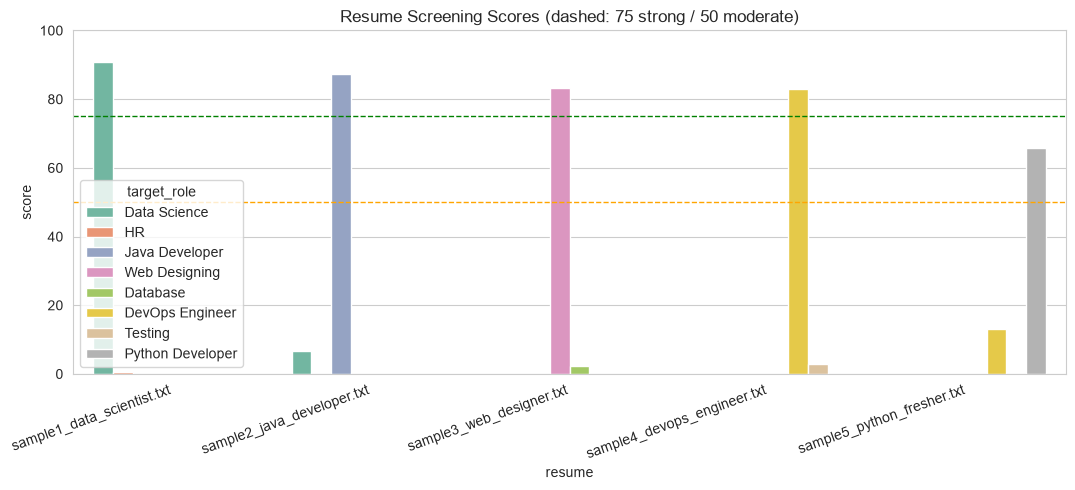

In [20]:
plt.figure(figsize=(11, 5))
sns.barplot(data=test_df, x="resume", y="score", hue="target_role", palette="Set2")
plt.axhline(75, ls="--", c="green", lw=1); plt.axhline(50, ls="--", c="orange", lw=1)
plt.xticks(rotation=20, ha="right"); plt.ylim(0, 100)
plt.title("Resume Screening Scores (dashed: 75 strong / 50 moderate)")
plt.tight_layout()
plt.savefig("screenshots/05_sample_scores.png", dpi=150)
plt.show()

## 10. Screen Your Own Resume
Paste resume text (or read from a `.txt` file) and choose a role from `ROLES`.

In [21]:
print("Available roles:", ROLES)
my_resume = open("sample_resumes/sample2_java_developer.txt").read()   # replace with your own file
_ = screen(my_resume, "Java Developer")

Available roles: ['Data Science', 'Python Developer', 'Java Developer', 'Web Designing', 'DevOps Engineer', 'Testing', 'Database', 'Network Security Engineer', 'HR']
Target Role          : Java Developer
Predicted Category   : Java Developer
Overall Score        : 87.2 / 100  ->  Strong Match
  Skill match        : 100%
  Text similarity    : 100%
  Classifier conf.   : 36.0%
Matched Skills       : java, spring, spring boot, hibernate, jpa, maven, junit, rest api, microservices, mysql, sql, git, jenkins
Missing Skills       : jsp, servlets, oop
Recommendation       : Learn/add -> jsp, servlets, oop
Top 3 Matching Roles : Java Developer (87.2), Python Developer (35.4), Testing (18.5)
